## Python options

The Python wrapper currently exposes the following options through `LsmashOptions`:

- `data_dir`  
  Specifies whether each sample is stored as a **row** or a **column** in the input data.  
  Default: `"row"`.

- `data_len`  
  The maximum number of data points read from the **beginning** of each sample.  
  This can be used to truncate long sequences during analysis.  
  Default: `10000000`.

- `data_type`  
  Specifies whether the input data are `"symbolic"` or `"continuous"`.

- `partition`  
  Used only when `data_type="continuous"`.  
  This defines the cut points used to discretize continuous-valued data into symbols.

- `use_derivative`  
  If enabled, the analysis is performed on the first differences of the sample data rather than on the raw values.  
  In other words, the input is transformed by taking a discrete derivative before running `lsmash`.

- `sae`  
  Controls whether the diagonal entries are computed using the classic **data smashing** self-annihilation estimate (SAE).  
  If enabled, the diagonal distances are estimated from self-annihilation.  
  If disabled, the diagonal entries remain zero.

- `num_repeat`  
  Number of repetitions used for the SAE computation.  
  This affects the stability of the diagonal self-annihilation estimate.  
  Default: `20`.

- `depth`  
  Depth parameter used in the SAE normalization step.

## Notes

For symbolic data, `partition` is ignored.

For continuous data, a valid `partition` must be supplied, since continuous values must first be converted into symbolic sequences before `lsmash` can be applied.

In most cases:
- use `data_dir="row"` if each sample is one row,
- use `data_type="symbolic"` for already discretized data,
- use `data_type="continuous"` together with `partition=[...]` for real-valued data,
- leave `sae=True` if you want meaningful diagonal self-distances.

In [1]:
import lsmash as ls

In [2]:
opt = ls.LsmashOptions()
opt.data_type = "symbolic"
opt.sae = True
opt.data_len = 1000
opt.data_dir = 'row'


In [3]:
D = ls.from_file("seq.dat", opt)
D

array([[0.03920722, 0.18036901, 0.12906895, 0.11336566],
       [0.18036901, 0.08872594, 0.16002797, 0.08238084],
       [0.12906895, 0.16002797, 0.05399568, 0.07764714],
       [0.11336566, 0.08238084, 0.07764714, 0.02959088]])

In [4]:
import seaborn as sns

<Axes: >

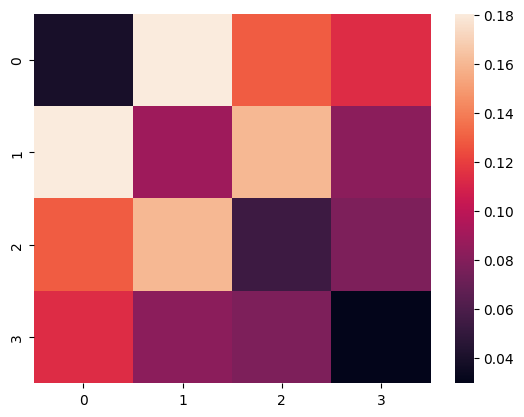

In [5]:
sns.heatmap(D)